# Thesis Figure 13 Ã¢â‚¬â€ FunnyBirds Explanation Visualization

Downloads per-sample artifacts from an MLflow visualization run
(`ciao-viz-*`) and produces publication-quality figures:

1. **original** Ã¢â‚¬â€ the FunnyBirds test image.
2. **ground truth** Ã¢â‚¬â€ semantic part overlay (eye / beak / wing / foot / tail).
3. **heatmap** Ã¢â‚¬â€ CIAO attribution (inferno, transparent outside found regions).
4. **regions** Ã¢â‚¬â€ each found region replaced with gray + probability-drop labels.
5. **composite strip** Ã¢â‚¬â€ all panels side by side.

Edit only the **Configuration** cell.

In [168]:
# Ã¢â€â‚¬Ã¢â€â‚¬ Configuration Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
# Parent run: set either RUN_ID (preferred) or RUN_NAME (slower search).
# Find the run ID in the MLflow UI: Experiments Ã¢â€ â€™ ciao-funnybirds Ã¢â€ â€™ run Ã¢â€ â€™ run ID.
MLFLOW_TRACKING_URI = "https://mlflow.rationai.cloud.e-infra.cz/"
MLFLOW_EXPERIMENT = "ciao-funnybirds"
MLFLOW_RUN_ID = (
    "64a44718c3f14b71bc450342ee1a250b"  # preferred: paste the parent run ID here
)
MLFLOW_RUN_NAME = "ciao-viz-ucb-slic-n800-reg5"  # fallback if RUN_ID is empty

# Credentials (or set env vars MLFLOW_TRACKING_USERNAME / MLFLOW_TRACKING_PASSWORD)
MLFLOW_USER = "YOUR_MLFLOW_USERNAME"
MLFLOW_PASSWORD = "YOUR_MLFLOW_PASSWORD"

# Which sample to visualise (0-indexed among the nested runs, sorted by name).
SAMPLE_IDX = 9

# Figure settings
HEATMAP_ALPHA = 0.35  # opacity of the inferno overlay
PANEL_FIGSIZE = (5, 5)  # per-panel figure size
STRIP_DPI = 150

OUTPUT_DIR = "output/13_funnybirds"

In [169]:
import json
import os
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
from mlflow.tracking import MlflowClient


OUT = Path(OUTPUT_DIR)
OUT.mkdir(parents=True, exist_ok=True)

# Ã¢â€â‚¬Ã¢â€â‚¬ Credentials Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
os.environ.setdefault("MLFLOW_TRACKING_USERNAME", MLFLOW_USER)
os.environ.setdefault("MLFLOW_TRACKING_PASSWORD", MLFLOW_PASSWORD)

client = MlflowClient(tracking_uri=MLFLOW_TRACKING_URI)
print(f"Connected to MLflow at {MLFLOW_TRACKING_URI}")

Connected to MLflow at https://mlflow.rationai.cloud.e-infra.cz/


In [170]:
# Ã¢â€â‚¬Ã¢â€â‚¬ Resolve parent run Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
experiment = client.get_experiment_by_name(MLFLOW_EXPERIMENT)
assert experiment is not None, f"Experiment '{MLFLOW_EXPERIMENT}' not found."
exp_id = experiment.experiment_id

if MLFLOW_RUN_ID:
    parent_run = client.get_run(MLFLOW_RUN_ID)
else:
    runs = client.search_runs(
        experiment_ids=[exp_id],
        filter_string=f"tags.`mlflow.runName` = '{MLFLOW_RUN_NAME}'",
        max_results=1,
    )
    assert runs, f"No run named '{MLFLOW_RUN_NAME}' found in '{MLFLOW_EXPERIMENT}'."
    parent_run = runs[0]

parent_run_id = parent_run.info.run_id
print(f"Parent run: {parent_run.data.tags.get('mlflow.runName', '')} | {parent_run_id}")

# Ã¢â€â‚¬Ã¢â€â‚¬ List nested sample runs Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
nested_runs = client.search_runs(
    experiment_ids=[exp_id],
    filter_string=f"tags.`mlflow.parentRunId` = '{parent_run_id}'",
    max_results=500,
)
nested_runs = sorted(nested_runs, key=lambda r: r.data.tags.get("mlflow.runName", ""))
print(f"Found {len(nested_runs)} nested sample runs.")
for i, r in enumerate(nested_runs):
    name = r.data.tags.get("mlflow.runName", "?")
    n_regions = r.data.metrics.get("n_regions", "?")
    prob = r.data.metrics.get("original_prob", float("nan"))
    drop = r.data.metrics.get("all_regions/probability_drop", float("nan"))
    print(
        f"  [{i:2d}] {name:<12}  n_regions={n_regions}  prob={prob:.3f}  drop={drop:.3f}"
    )

Parent run: ciao-viz-ucb-slic-n800-reg5 | 64a44718c3f14b71bc450342ee1a250b
Found 20 nested sample runs.
  [ 0] sample_0      n_regions=5.0  prob=1.000  drop=1.000
  [ 1] sample_1      n_regions=5.0  prob=1.000  drop=0.999
  [ 2] sample_10     n_regions=5.0  prob=1.000  drop=0.997
  [ 3] sample_11     n_regions=5.0  prob=1.000  drop=1.000
  [ 4] sample_12     n_regions=5.0  prob=1.000  drop=0.999
  [ 5] sample_13     n_regions=5.0  prob=0.906  drop=0.906
  [ 6] sample_14     n_regions=5.0  prob=1.000  drop=1.000
  [ 7] sample_15     n_regions=5.0  prob=1.000  drop=1.000
  [ 8] sample_16     n_regions=5.0  prob=0.998  drop=0.835
  [ 9] sample_17     n_regions=5.0  prob=0.849  drop=0.849
  [10] sample_18     n_regions=5.0  prob=1.000  drop=1.000
  [11] sample_19     n_regions=5.0  prob=1.000  drop=0.981
  [12] sample_2      n_regions=5.0  prob=1.000  drop=0.997
  [13] sample_3      n_regions=5.0  prob=1.000  drop=1.000
  [14] sample_4      n_regions=5.0  prob=1.000  drop=1.000
  [15] samp

In [171]:
# Ã¢â€â‚¬Ã¢â€â‚¬ Download artifacts for the selected sample Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
sample_run = nested_runs[SAMPLE_IDX]
sample_run_id = sample_run.info.run_id
sample_name = sample_run.data.tags.get("mlflow.runName", f"sample_{SAMPLE_IDX}")
print(f"Loading: [{SAMPLE_IDX}] {sample_name} (run_id={sample_run_id})")

artifact_dir = Path(client.download_artifacts(sample_run_id, "artifacts"))
print(f"Artifacts at: {artifact_dir}")
print(list(artifact_dir.iterdir()))

# Ã¢â€â‚¬Ã¢â€â‚¬ Load arrays Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
img = np.load(artifact_dir / "original.npy")  # [H, W, 3] float32 [0, 1]
attr_hw = np.load(artifact_dir / "attribution.npy")  # [H, W] float32
segs = np.load(artifact_dir / "segmentation.npy")  # [H, W] int32

with open(artifact_dir / "regions.json") as f:
    regions_data = json.load(f)  # list of {segment_ids, score, probability_drop, ...}

part_map_path = artifact_dir / "part_map.npy"
part_map_hw3 = np.load(part_map_path) if part_map_path.exists() else None

print(f"Image shape: {img.shape}")
print(f"Attribution non-zero pixels: {(attr_hw > 0).sum()}")
print(f"Regions: {len(regions_data)}")
print(f"Part map available: {part_map_hw3 is not None}")

Loading: [9] sample_17 (run_id=e65b614cdb4943cf9d172a9306dba280)


Artifacts at: TEMP_DIR/tmpta1or1t3\artifacts
[WindowsPath('TEMP_DIR/tmpta1or1t3/artifacts/attribution.npy'), WindowsPath('TEMP_DIR/tmpta1or1t3/artifacts/original.npy'), WindowsPath('TEMP_DIR/tmpta1or1t3/artifacts/part_map.npy'), WindowsPath('TEMP_DIR/tmpta1or1t3/artifacts/regions.json'), WindowsPath('TEMP_DIR/tmpta1or1t3/artifacts/segmentation.npy'), WindowsPath('TEMP_DIR/tmpta1or1t3/artifacts/segment_scores.json')]
Image shape: (256, 256, 3)
Attribution non-zero pixels: 6517
Regions: 5
Part map available: True


In [172]:
# Ã¢â€â‚¬Ã¢â€â‚¬ Shared helpers Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
from scipy.ndimage import binary_dilation


_REGION_COLORS = [
    (0.9, 0.2, 0.2),
    (0.2, 0.6, 0.9),
    (0.2, 0.8, 0.3),
    (0.95, 0.7, 0.1),
    (0.8, 0.2, 0.8),
]

_PART_DISPLAY = {
    (255, 255, 253): ("eye", (0.2, 0.85, 0.95)),
    (255, 255, 254): ("eye", (0.2, 0.85, 0.95)),
    (255, 255, 0): ("beak", (1.0, 0.90, 0.00)),
    (255, 0, 1): ("foot", (0.9, 0.50, 0.10)),
    (255, 0, 2): ("foot", (0.9, 0.50, 0.10)),
    (0, 255, 1): ("wing", (0.2, 0.90, 0.30)),
    (0, 255, 2): ("wing", (0.2, 0.90, 0.30)),
    (0, 0, 255): ("tail", (0.7, 0.20, 0.90)),
}


def region_pixel_mask(rd: dict) -> np.ndarray:
    """Boolean [H, W] mask for a region dict from regions.json."""
    mask = np.zeros(segs.shape, dtype=bool)
    for sid in rd["segment_ids"]:
        mask |= segs == sid
    return mask


def save(fig: plt.Figure, name: str) -> None:
    fig.savefig(OUT / f"{name}.png", dpi=STRIP_DPI, bbox_inches="tight")
    print(f"Saved Ã¢â€ â€™ {OUT / name}.png")

Saved Ã¢â€ â€™ output\13_funnybirds\sample_17_original.png


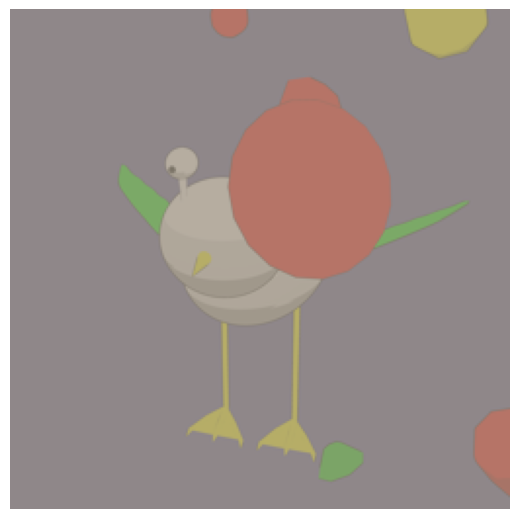

In [173]:
# Ã¢â€â‚¬Ã¢â€â‚¬ Figure: original image Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
fig, ax = plt.subplots(figsize=PANEL_FIGSIZE)
ax.imshow(img)
ax.axis("off")
fig.tight_layout(pad=0)
save(fig, f"{sample_name}_original")
plt.show()

Saved Ã¢â€ â€™ output\13_funnybirds\sample_17_ground_truth.png


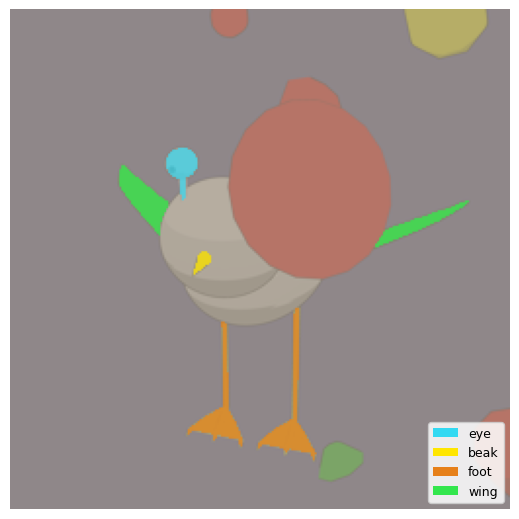

In [174]:
# Ã¢â€â‚¬Ã¢â€â‚¬ Figure: ground truth part overlay Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
if part_map_hw3 is None:
    print("No part map available Ã¢â‚¬â€ skipping ground truth figure.")
else:
    overlay = img.copy()
    legend_patches = []
    seen: set[str] = set()
    for rgb, (part_name, color) in _PART_DISPLAY.items():
        mask = np.all(part_map_hw3 == np.array(rgb, dtype=np.uint8), axis=-1)
        if not mask.any():
            continue
        c = np.array(color, dtype=np.float32)
        overlay[mask] = img[mask] * 0.3 + c * 0.7
        if part_name not in seen:
            legend_patches.append(mpatches.Patch(facecolor=color, label=part_name))
            seen.add(part_name)

    fig, ax = plt.subplots(figsize=PANEL_FIGSIZE)
    ax.imshow(overlay)
    ax.axis("off")
    if legend_patches:
        ax.legend(
            handles=legend_patches,
            loc="lower right",
            fontsize=9,
            framealpha=0.85,
            edgecolor="#cccccc",
        )
    fig.tight_layout(pad=0)
    save(fig, f"{sample_name}_ground_truth")
    plt.show()

Saved Ã¢â€ â€™ output\13_funnybirds\sample_17_heatmap.png


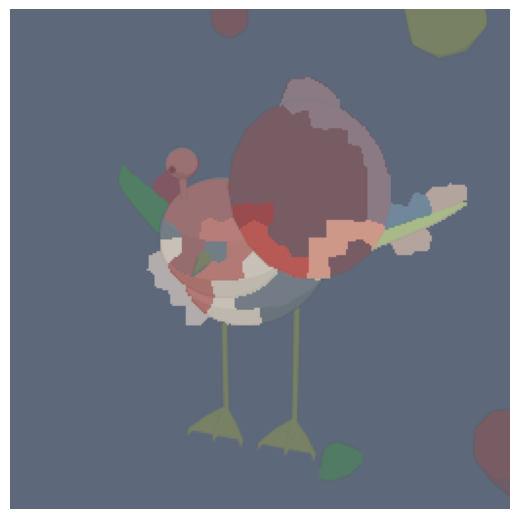

In [175]:
# Ã¢â€â‚¬Ã¢â€â‚¬ Figure: attribution heatmap Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
region_mask = attr_hw >= 0
attr_disp = np.where(region_mask, attr_hw, np.nan)

cmap = plt.cm.RdBu_r.copy()
cmap.set_bad(alpha=0)  # transparent for NaN (non-region) pixels

fig, ax = plt.subplots(figsize=PANEL_FIGSIZE)
ax.imshow(img)
if region_mask.any():
    ax.imshow(
        attr_disp,
        cmap=cmap,
        vmin=0,
        vmax=float(np.nanmax(attr_disp)),
        alpha=HEATMAP_ALPHA,
    )
ax.axis("off")
fig.tight_layout(pad=0)
save(fig, f"{sample_name}_heatmap")
plt.show()

Saved Ã¢â€ â€™ output\13_funnybirds\sample_17_heatmap_boundaries.png


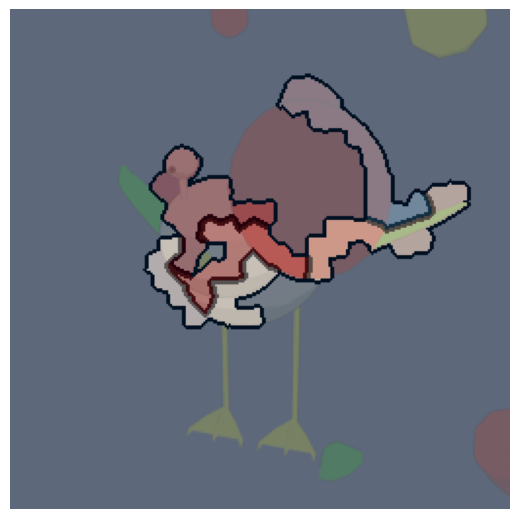

In [176]:
# Ã¢â€â‚¬Ã¢â€â‚¬ Figure: heatmap with black region boundaries Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
canvas = img.copy()
for rd in regions_data:
    mask = region_pixel_mask(rd)
    boundary = binary_dilation(mask, iterations=2) & ~mask
    canvas[boundary] = 0.0

fig, ax = plt.subplots(figsize=PANEL_FIGSIZE)
ax.imshow(canvas)
if region_mask.any():
    ax.imshow(
        attr_disp,
        cmap=cmap,
        vmin=0,
        vmax=float(np.nanmax(attr_disp)),
        alpha=HEATMAP_ALPHA,
    )
ax.axis("off")
fig.tight_layout(pad=0)
save(fig, f"{sample_name}_heatmap_boundaries")
plt.show()

Saved Ã¢â€ â€™ output\13_funnybirds\sample_17_regions.png


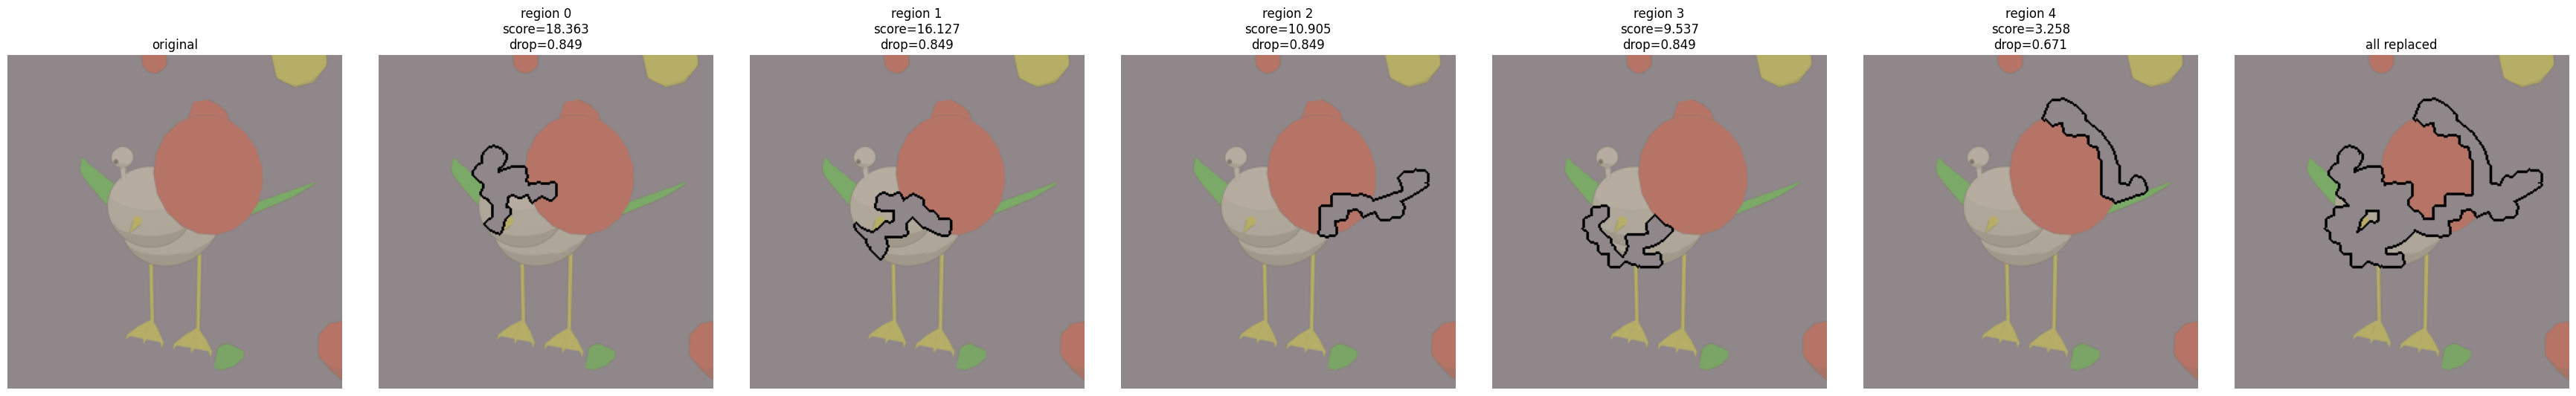

In [177]:
# Ã¢â€â‚¬Ã¢â€â‚¬ Figure: per-region replacement panels Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
# solid replacement colour (matches CIAO's default)
REPL_COLOR = np.array([143, 135, 137], dtype=np.float32) / 255.0

n = len(regions_data)
ncols = n + 2  # original + per-region + all-replaced

fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 5))
axes[0].imshow(img)
axes[0].set_title("original")
axes[0].axis("off")

all_mask = np.zeros(segs.shape, dtype=bool)
for idx, rd in enumerate(regions_data):
    mask = region_pixel_mask(rd)
    all_mask |= mask
    single = img.copy()
    single[mask] = REPL_COLOR
    boundary = binary_dilation(mask, iterations=2) & ~mask
    single[boundary] = 0.0
    axes[idx + 1].imshow(single)
    axes[idx + 1].set_title(
        f"region {idx}\nscore={rd['score']:.3f}\ndrop={rd['probability_drop']:.3f}"
    )
    axes[idx + 1].axis("off")

merged = img.copy()
merged[all_mask] = REPL_COLOR
all_boundary = binary_dilation(all_mask, iterations=2) & ~all_mask
merged[all_boundary] = 0.0
axes[-1].imshow(merged)
axes[-1].set_title("all replaced")
axes[-1].axis("off")

fig.tight_layout(pad=0.5)
save(fig, f"{sample_name}_regions")
plt.show()

Saved Ã¢â€ â€™ output\13_funnybirds\sample_17_strip.png


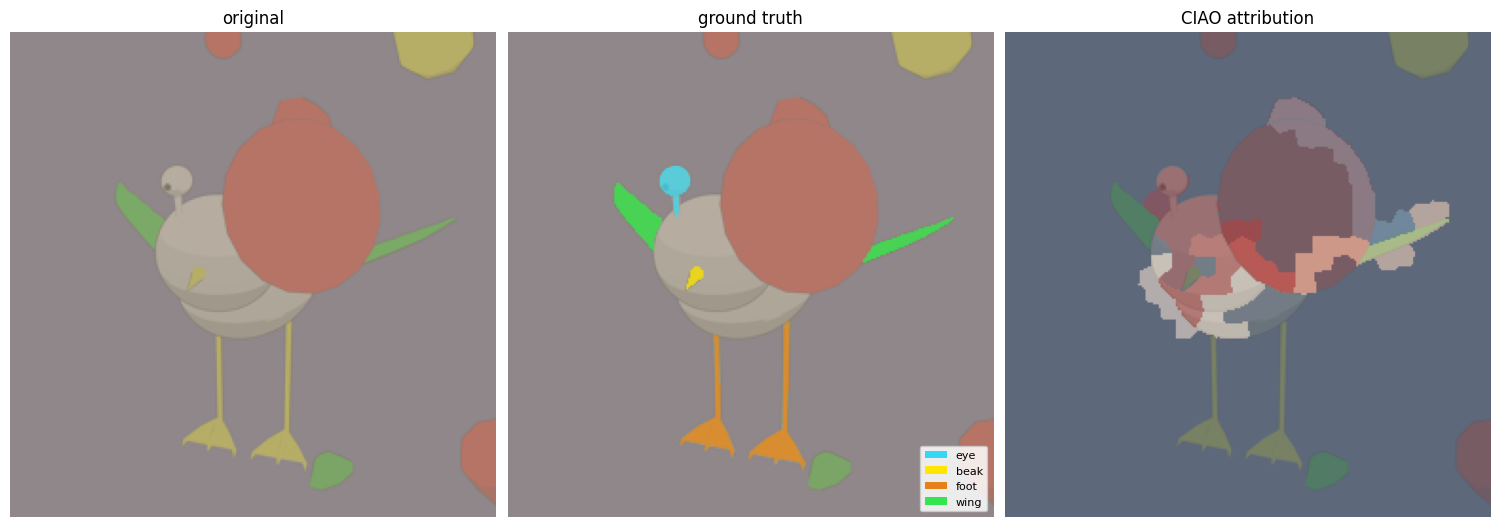

In [178]:
# Ã¢â€â‚¬Ã¢â€â‚¬ Figure: composite strip (original | ground truth | heatmap) Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
ncols_strip = 3 if part_map_hw3 is not None else 2
fig, axes = plt.subplots(1, ncols_strip, figsize=(5 * ncols_strip, 5))

axes[0].imshow(img)
axes[0].set_title("original")
axes[0].axis("off")

col = 1
if part_map_hw3 is not None:
    overlay = img.copy()
    legend_patches_strip = []
    seen_strip: set[str] = set()
    for rgb, (part_name, color) in _PART_DISPLAY.items():
        mask = np.all(part_map_hw3 == np.array(rgb, dtype=np.uint8), axis=-1)
        if not mask.any():
            continue
        c = np.array(color, dtype=np.float32)
        overlay[mask] = img[mask] * 0.3 + c * 0.7
        if part_name not in seen_strip:
            legend_patches_strip.append(
                mpatches.Patch(facecolor=color, label=part_name)
            )
            seen_strip.add(part_name)
    axes[col].imshow(overlay)
    axes[col].set_title("ground truth")
    axes[col].axis("off")
    if legend_patches_strip:
        axes[col].legend(
            handles=legend_patches_strip,
            loc="lower right",
            fontsize=8,
            framealpha=0.85,
            edgecolor="#cccccc",
        )
    col += 1

strip_cmap = plt.cm.RdBu_r.copy()
strip_cmap.set_bad(alpha=0)

axes[col].imshow(img)
if region_mask.any():
    axes[col].imshow(
        attr_disp,
        cmap=strip_cmap,
        vmin=0,
        vmax=float(np.nanmax(attr_disp)),
        alpha=HEATMAP_ALPHA,
    )
axes[col].set_title("CIAO attribution")
axes[col].axis("off")

fig.tight_layout(pad=0.5)
save(fig, f"{sample_name}_strip")
plt.show()